In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
df= df.drop('id',axis =1 )

In [5]:
categorical_features = ['gender',  'hypertension' , 	'heart_disease' ,	'ever_married' , 'work_type' , 'Residence_type' ,	'avg_glucose_level' , 'smoking_status']

In [6]:
unique_values = {col:df[col].unique() for col in categorical_features}

In [7]:
for col , values in unique_values.items():
    print(f"{col} : {values}")

gender : ['Male' 'Female' 'Other']
hypertension : [0 1]
heart_disease : [1 0]
ever_married : ['Yes' 'No']
work_type : ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type : ['Urban' 'Rural']
avg_glucose_level : [228.69 202.21 105.92 ...  82.99 166.29  85.28]
smoking_status : ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [10]:
y = df['stroke']
y.value_counts(normalize = True)*100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [11]:
import plotly.express as px

In [12]:
px.bar(x = y.value_counts().index , y = y.value_counts() , color = y.value_counts().index)

In [13]:
numerical_features = ['age','avg_glucose_level','bmi']

In [14]:
df[numerical_features].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'avg_glucose_level'}>],
       [<Axes: title={'center': 'bmi'}>, <Axes: >]], dtype=object)

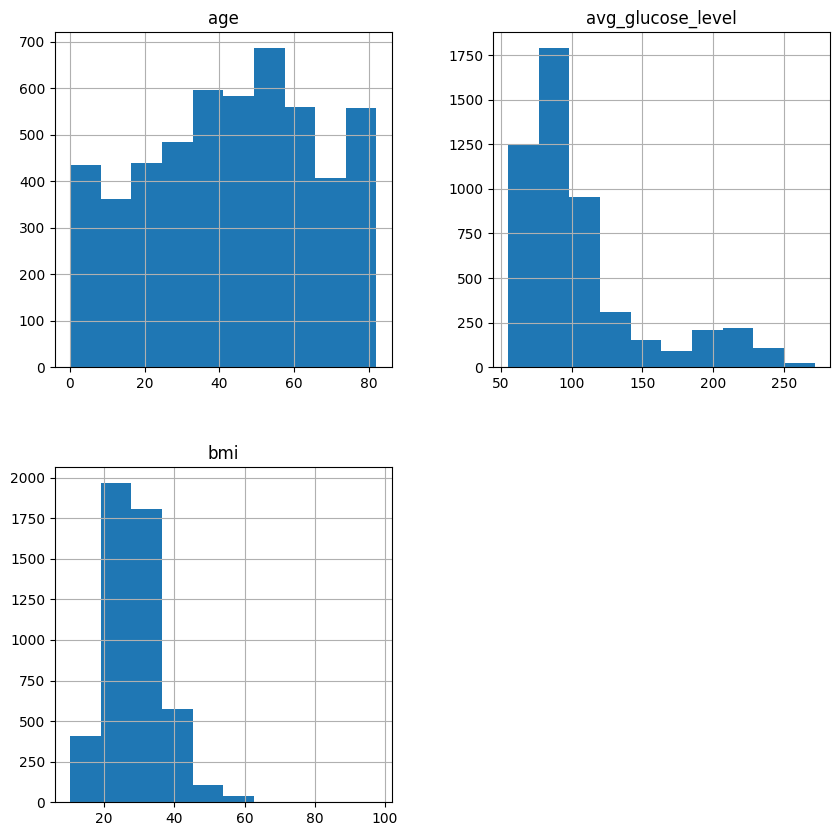

In [15]:
df[numerical_features].hist(figsize=(10,10))

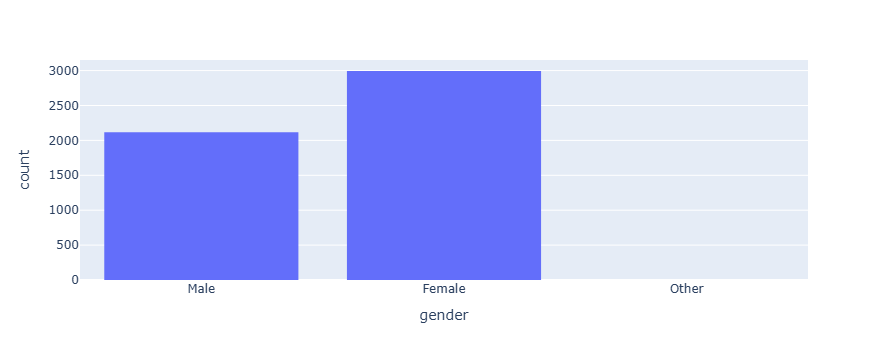

In [16]:
fig = px.histogram(df,x = 'gender' , width = 400)
fig.show()

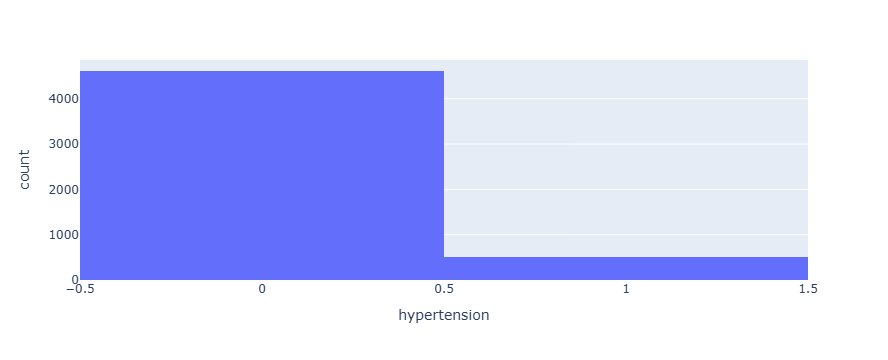

In [17]:
fig = px.histogram(df,x = 'hypertension' , width = 400)
fig.show()

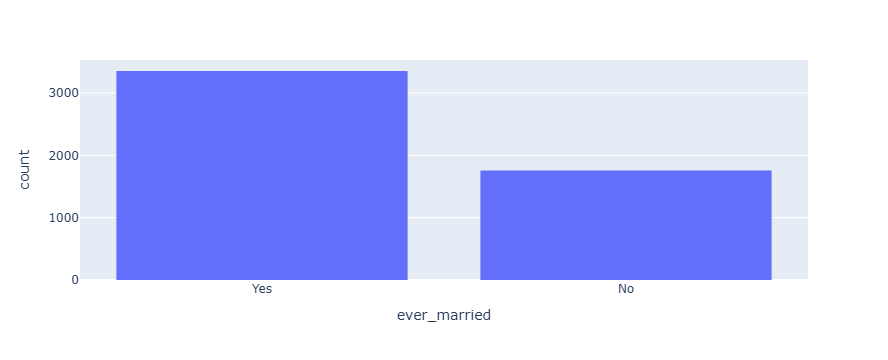

In [18]:
fig = px.histogram(df,x = 'ever_married' , width = 400)
fig.show()

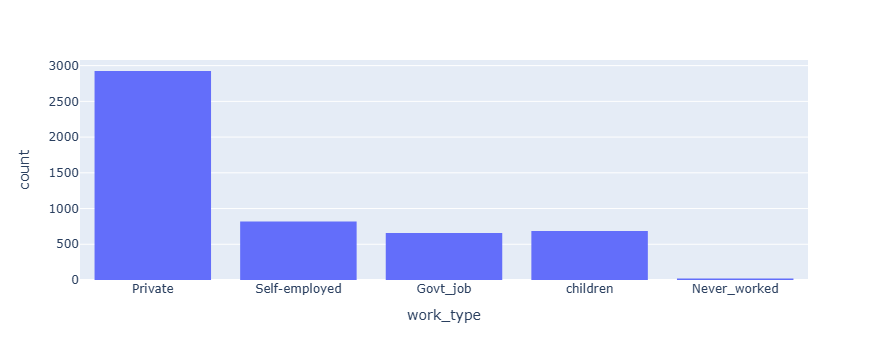

In [19]:
fig = px.histogram(df,x = 'work_type' , width = 400)
fig.show()

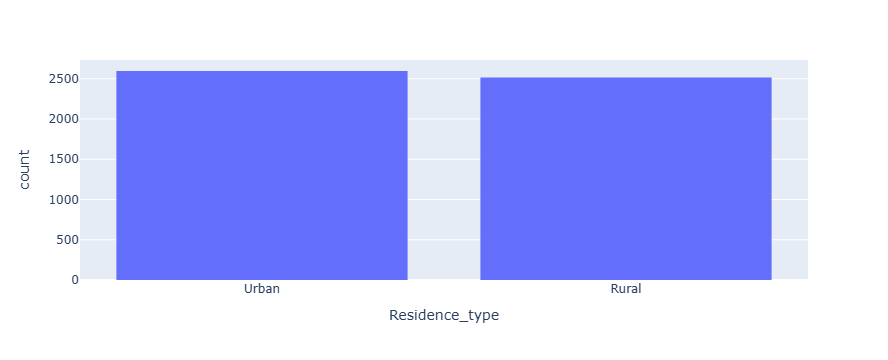

In [20]:
fig = px.histogram(df,x = 'Residence_type' , width = 400)
fig.show()

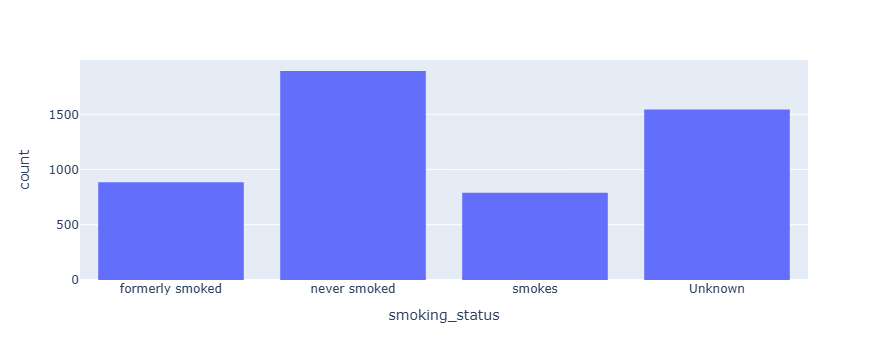

In [21]:
fig = px.histogram(df,x = 'smoking_status' , width = 400)
fig.show()

In [22]:
from sklearn.metrics import mutual_info_score

In [23]:
categorical_features = ['gender',  'hypertension' , 	'heart_disease' ,	'ever_married' , 'work_type' , 'Residence_type' ,	'avg_glucose_level' , 'smoking_status']
for col in categorical_features:
    mi = mutual_info_score(df[col],df['stroke'])
    print(f"{col} : {mi:.2f}")

gender : 0.00
hypertension : 0.01
heart_disease : 0.01
ever_married : 0.01
work_type : 0.01
Residence_type : 0.00
avg_glucose_level : 0.17
smoking_status : 0.00


C:\Users\Anushka\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:66: UserWarning:

Clustering metrics expects discrete values but received continuous values for label, and binary values for target



In [24]:
df[numerical_features+['stroke']].corr()

,age,avg_glucose_level,bmi,stroke
age,1.000000,0.238171,0.333398,0.245257
avg_glucose_level,0.238171,1.000000,0.175502,0.131945
bmi,0.333398,0.175502,1.000000,0.042374
stroke,0.245257,0.131945,0.042374,1.000000


In [25]:
pip install scikit-learn==1.5.2 imbalanced-learn==0.12.4

Note: you may need to restart the kernel to use updated packages.


In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np
from joblib import dump
import matplotlib.pyplot as plt

In [27]:
def load_data():
    df = pd.read_csv('healthcare-dataset-stroke-data.csv')
    df = df.drop('id', axis=1)
    categorical = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
    numerical = ['avg_glucose_level', 'bmi', 'age']
    y = df['stroke']
    X = df.drop('stroke', axis=1)
    return X, y, categorical, numerical

In [28]:
def evaluate_model(X, y, model):
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
    scores = cross_val_score(model, X, y, scoring='roc_auc', cv=cv, n_jobs=-1)
    return scores

In [29]:
# Load data
X, y, categorical, numerical = load_data()
print(X.shape, y.shape)

(5110, 10) (5110,)


In [30]:
# Define the LDA model
model = LinearDiscriminantAnalysis()

In [31]:
# Prepare the pipeline
transformer = ColumnTransformer(transformers=[
    ('imp', SimpleImputer(strategy='median'), numerical),
    ('o', OneHotEncoder(handle_unknown='ignore'), categorical)  # handle_unknown='ignore' to manage unseen categories
])

In [32]:
pipeline = Pipeline(steps=[
    ('t', transformer),
    ('p', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('over', SMOTE()),
    ('m', model)
])

In [33]:
# Evaluate the model
scores = evaluate_model(X, y, pipeline)
print('LDA %.3f (%.3f)' % (np.mean(scores), np.std(scores)))


LDA 0.839 (0.030)


C:\Users\Anushka\AppData\Local\Temp\ipykernel_51368\1060317285.py:2: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



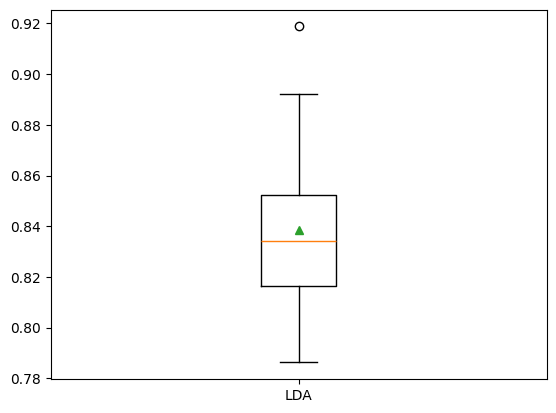

In [34]:
# Plot the results
plt.boxplot([scores], labels=['LDA'], showmeans=True)
plt.show()

In [35]:
# Fit the pipeline on the entire dataset
pipeline.fit(X, y)

Pipeline(steps=[('t',
                 ColumnTransformer(transformers=[('imp',
                                                  SimpleImputer(strategy='median'),
                                                  ['avg_glucose_level', 'bmi',
                                                   'age']),
                                                 ('o',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['hypertension',
                                                   'heart_disease',
                                                   'ever_married', 'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('p', PowerTransformer()), ('over', SMOTE()),
                ('m', LinearDiscriminantAnalysis())])

In [36]:
# Save the trained pipeline
dump(pipeline, 'stroke_prediction_model.joblib')

['stroke_prediction_model.joblib']